# Portfolio Optimization using Kenneth French 30 Industry Portfolios
### Global Minimum Variance (GMV) vs. Equal Weight vs. Maximum Sharpe Ratio

**Author:** Sahil | BITS Pilani, Mathematics & Computing
**Objective:** Implement and analyze the Global Minimum Variance portfolio on the Ken French 30 Industry universe, benchmarked against naive 1/N allocation, using classical Modern Portfolio Theory (Markowitz, 1952).

This notebook walks through the full research pipeline interactively. The same logic is packaged into reusable modules under `src/` and orchestrated by `main.py` for production/CLI use.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import data_loader, optimizer, metrics, visualization

pd.set_option('display.float_format', lambda x: f'{x:.4f}')
%matplotlib inline

## 1. Data Loading

We load the Kenneth French 30 Industry Portfolios monthly value-weighted return dataset. The loader attempts to download the official dataset from the Ken French Data Library; if network access is unavailable (e.g. in a sandboxed environment), it falls back to a clearly-labeled synthetic dataset that mimics the real statistical structure (single dominant market factor + heterogeneous industry betas/vols), so the full pipeline remains reproducible end-to-end.

In [2]:
returns_df = data_loader.load_industry_returns()
print(f"Shape: {returns_df.shape}")
print(f"Date range: {returns_df.index.min().date()} to {returns_df.index.max().date()}")
returns_df.tail()

[INFO] Loading cached dataset from /home/claude/portfolio-optimization/data/30_Industry_Portfolios_monthly.csv


Shape: (420, 30)
Date range: 1991-07-01 to 2026-06-01


,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
2026-02-01,-6.4100,2.1100,-9.2100,-8.7300,0.4300,-7.7100,-4.5300,-8.2100,-2.2000,-0.1700,...,-7.7100,-6.4800,-5.9300,-6.9400,4.8200,-5.7800,-5.6300,-13.1800,-7.2200,-5.3200
2026-03-01,-14.7700,-10.5300,-13.0400,-8.4500,-2.3400,-1.8700,-9.8300,-4.8200,-13.7700,-8.9900,...,-7.9100,-10.7800,-14.9100,-9.1300,-17.8500,-7.0700,-19.3600,-15.1400,-13.1300,-15.3400
2026-04-01,-0.4200,0.1400,-4.6300,1.2600,-3.4500,7.7400,-1.2600,-6.5700,-4.7800,6.2400,...,-1.5700,5.1500,10.2400,6.4700,-5.7800,-5.3200,-4.9900,-5.3000,3.4300,-1.8700
2026-05-01,12.4800,13.4400,7.9800,15.9600,-1.0200,5.7700,10.5500,7.3700,12.2800,9.7600,...,7.2400,11.4500,13.8400,12.6700,6.1900,18.3900,11.2700,20.7300,9.8800,12.6500
2026-06-01,12.4400,3.5600,13.4500,3.2100,2.8400,8.7100,-1.2900,-5.1000,0.0800,7.2400,...,1.2700,2.5200,5.8100,-9.4900,1.2600,2.8900,6.6000,12.3300,4.0600,0.9300


## 2. Expected Returns and Covariance Matrix

- **Expected return** $\mu_i$: historical sample mean of monthly returns, annualized via compounding: $\mu_{annual} = (1+\mu_{monthly})^{12} - 1$
- **Covariance matrix** $\Sigma$: sample covariance of monthly returns, annualized by scaling by 12 under the i.i.d.-returns assumption.

In [3]:
mu = data_loader.compute_expected_returns(returns_df, annualize=True)
cov = data_loader.compute_covariance_matrix(returns_df, annualize=True)

print("Expected annual returns (top 5):")
print(mu.sort_values(ascending=False).head())
print("\nAnnualized volatilities (top 5):")
print(pd.Series(np.sqrt(np.diag(cov)), index=cov.index).sort_values(ascending=False).head())

Expected annual returns (top 5):
Steel   0.3114
Games   0.2741
Oil     0.2575
BusEq   0.2451
Rtail   0.2324
dtype: float64

Annualized volatilities (top 5):
BusEq   0.2981
Steel   0.2865
Oil     0.2861
Food    0.2768
Beer    0.2752
dtype: float64


## 3. Portfolio Optimization

### 3.1 Global Minimum Variance (GMV)

$$\min_{w} \; w' \Sigma w \quad \text{s.t.} \quad \mathbf{1}'w = 1, \; w_i \ge 0$$

Solved numerically with `scipy.optimize.minimize` (SLSQP). We cross-check the unconstrained (shorting-allowed) numerical solution against the closed-form solution:

$$w^* = \frac{\Sigma^{-1}\mathbf{1}}{\mathbf{1}'\Sigma^{-1}\mathbf{1}}$$

In [4]:
gmv = optimizer.solve_gmv(cov, mu, long_only=True)
gmv_unconstrained = optimizer.solve_gmv(cov, mu, long_only=False)
gmv_cf = optimizer.gmv_closed_form(cov)
cf_vol = float(np.sqrt(gmv_cf.values @ cov.values @ gmv_cf.values))

print(f"GMV (long-only) volatility:      {gmv.volatility:.4%}")
print(f"GMV (unconstrained) volatility:  {gmv_unconstrained.volatility:.4%}")
print(f"GMV (closed-form) volatility:    {cf_vol:.4%}  <- sanity check, should match unconstrained")

GMV (long-only) volatility:      10.9258%
GMV (unconstrained) volatility:  9.3659%
GMV (closed-form) volatility:    9.3659%  <- sanity check, should match unconstrained


### 3.2 Equal Weight (1/N) Benchmark

The naive $w_i = 1/N$ portfolio — a surprisingly strong benchmark (DeMiguel, Garlappi & Uppal, 2009).

### 3.3 Maximum Sharpe Ratio (Tangency Portfolio)

$$\max_w \; \frac{w'\mu - r_f}{\sqrt{w'\Sigma w}} \quad \text{s.t.} \quad \mathbf{1}'w=1,\; w_i \ge 0$$

In [5]:
ew = optimizer.solve_equal_weight(cov, mu)
msr = optimizer.solve_max_sharpe(cov, mu, risk_free_rate=0.0, long_only=True)

weights_dict = {"GMV": gmv.weights, "Equal Weight": ew.weights, "Max Sharpe": msr.weights}
pd.DataFrame(weights_dict).sort_values("GMV", ascending=False).head(10)

,GMV,Equal Weight,Max Sharpe
Hshld,0.2709,0.0333,0.2258
Books,0.2653,0.0333,0.0761
Servs,0.1960,0.0333,0.0000
Coal,0.1287,0.0333,0.1260
Txtls,0.0666,0.0333,0.0000
Beer,0.0487,0.0333,0.0368
Carry,0.0237,0.0333,0.0000
Trans,0.0000,0.0333,0.0332
Cnstr,0.0000,0.0333,0.0000
Games,0.0000,0.0333,0.0611


## 4. Performance Metrics

Applying each portfolio's weights to realized monthly history:
- **Annualized Return (CAGR)**
- **Annualized Volatility**
- **Sharpe Ratio**
- **Maximum Drawdown**
- **Effective N (1/HHI)** — a diversification measure (Herfindahl-Hirschman Index based); Equal Weight always has Effective N = 30, GMV typically concentrates into fewer, low-vol industries.

In [6]:
summary = metrics.summary_table(returns_df, weights_dict)
summary

,Annualized Return,Annualized Volatility,Sharpe Ratio,Max Drawdown,Effective N (1/HHI)
Portfolio,,,,,
GMV,0.1191,0.1093,1.0898,-0.1756,4.8510
Equal Weight,0.1532,0.1558,0.9836,-0.2780,30.0000
Max Sharpe,0.1832,0.1464,1.2508,-0.2697,7.3346


In [7]:
corr = metrics.correlation_matrix(returns_df)
avg_corr = (corr.values.sum() - len(corr)) / (len(corr)**2 - len(corr))
print(f"Average pairwise industry correlation: {avg_corr:.3f}")

Average pairwise industry correlation: 0.438


## 5. Efficient Frontier

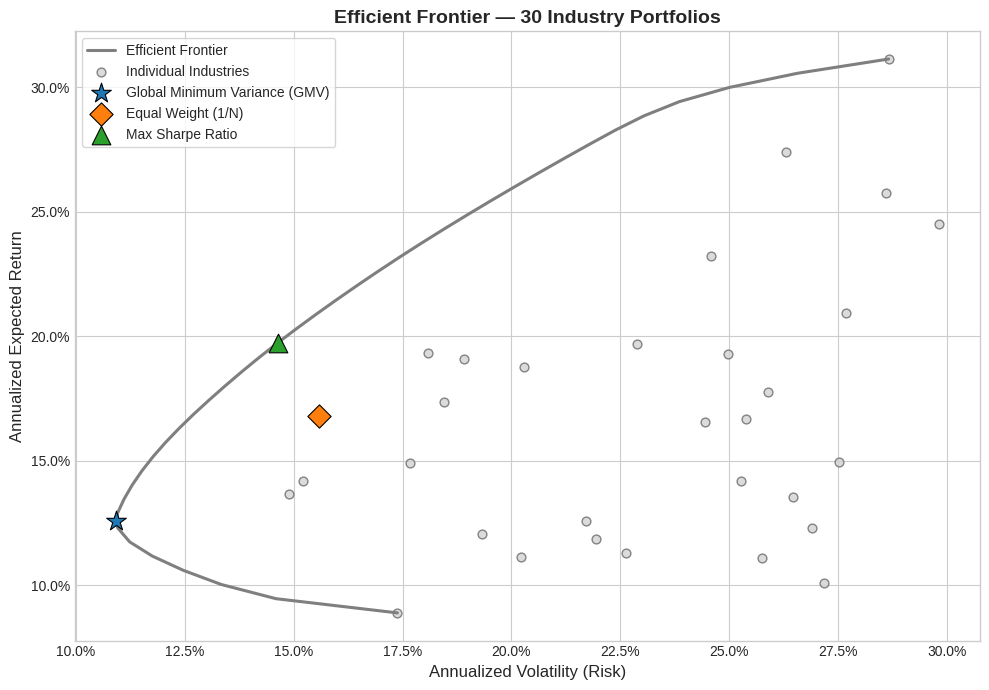

In [8]:
frontier = optimizer.compute_efficient_frontier(cov, mu, n_points=40, long_only=True)

individual_assets = pd.DataFrame({
    "volatility": np.sqrt(np.diag(cov)),
    "return": mu.values,
}, index=cov.index)

fig = visualization.plot_efficient_frontier(
    frontier_df=frontier,
    gmv_point=(gmv.volatility, gmv.expected_return),
    ew_point=(ew.volatility, ew.expected_return),
    msr_point=(msr.volatility, msr.expected_return),
    individual_assets=individual_assets,
)
plt.show()

## 6. Portfolio Allocation

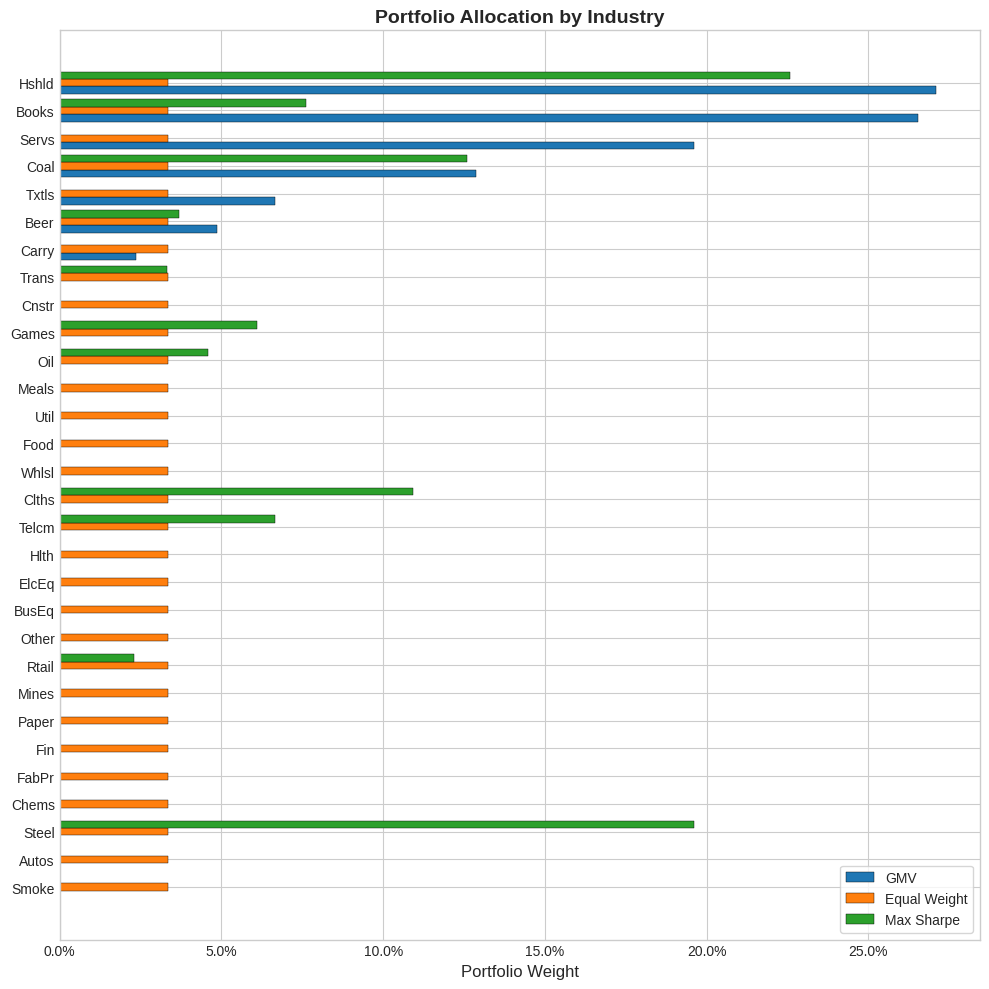

In [9]:
fig = visualization.plot_portfolio_allocation(weights_dict)
plt.show()

## 7. Correlation Heatmap

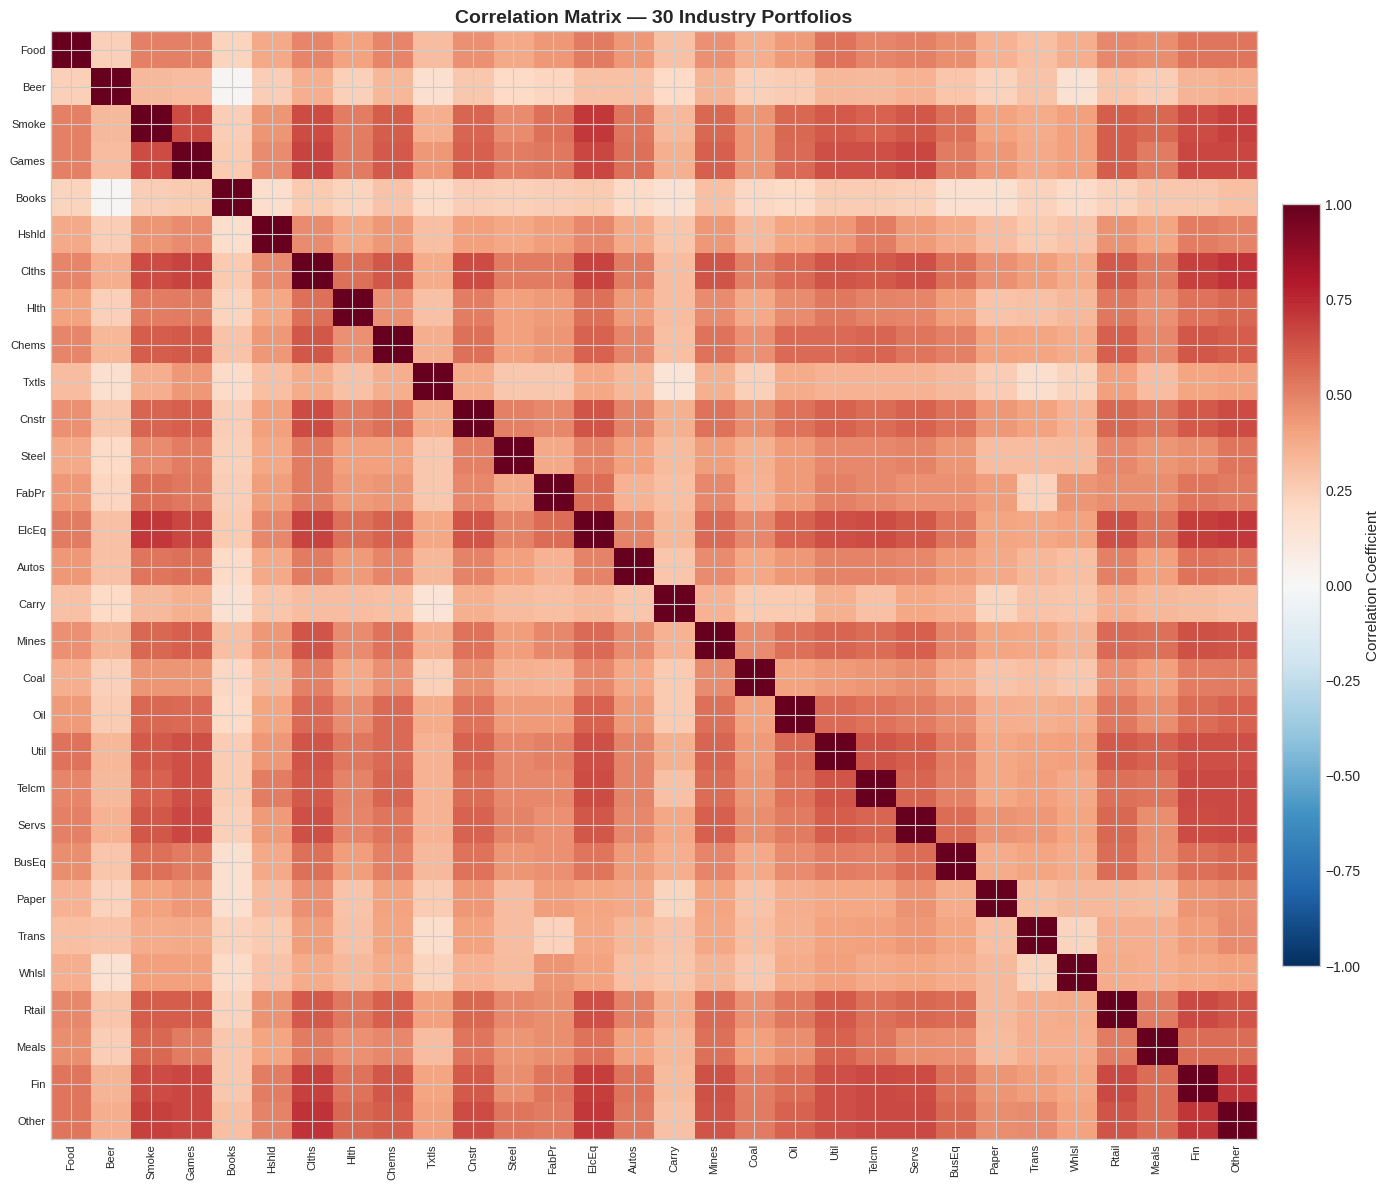

In [10]:
fig = visualization.plot_correlation_heatmap(corr)
plt.show()

## 8. Cumulative Returns & Rolling Volatility

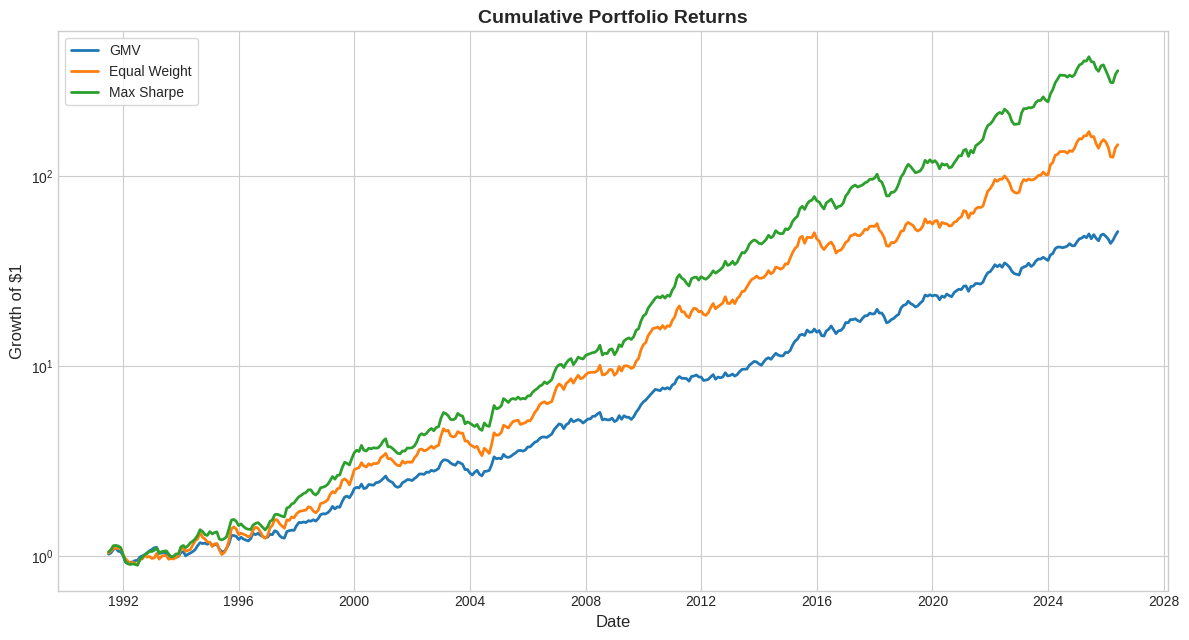

In [11]:
cum_returns_dict = {
    name: metrics.cumulative_returns(metrics.portfolio_monthly_returns(returns_df, w))
    for name, w in weights_dict.items()
}
fig = visualization.plot_cumulative_returns(cum_returns_dict)
plt.show()

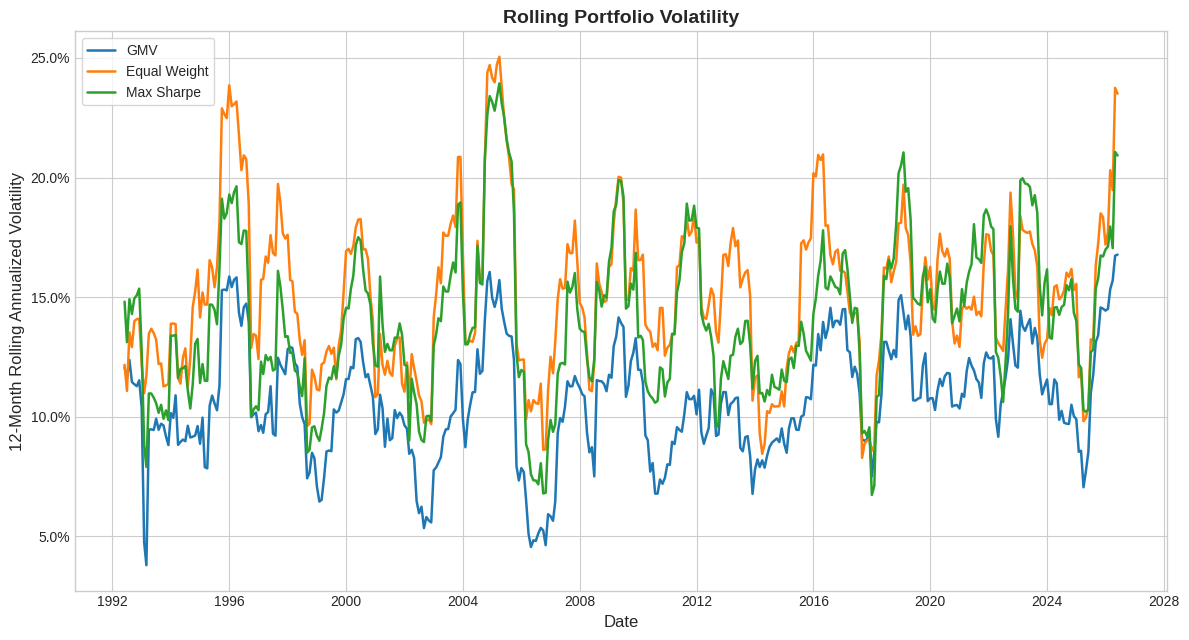

In [12]:
rolling_vol_dict = {
    name: metrics.rolling_volatility(metrics.portfolio_monthly_returns(returns_df, w))
    for name, w in weights_dict.items()
}
fig = visualization.plot_rolling_volatility(rolling_vol_dict)
plt.show()

## 9. Key Takeaways

1. **GMV materially reduces volatility** relative to Equal Weight, at some cost to expected return — exactly as MPT predicts for the leftmost point of the efficient frontier.
2. **GMV concentrates** into a smaller set of low-volatility, weakly-correlated industries (lower Effective N), while Equal Weight is maximally diversified by construction but ignores risk information entirely.
3. **Max Sharpe** portfolio achieves the best risk-adjusted return in-sample, but is the most sensitive to estimation error in $\mu$ — a key MPT/practitioner critique (Michaud, 1989), motivating why GMV (which ignores $\mu$ entirely) is often preferred as a robust, real-world allocation baseline.
4. See `README.md` for the full mathematical writeup and discussion of limitations / future improvements (shrinkage covariance estimators, Black-Litterman, factor models, transaction costs, out-of-sample rolling backtests).